# Complete exploratory analysis — RQ9, RQ9 extension and RQ12

This notebook uses only the supplied `raw_data` and answers:

1. **RQ9:** Does larger inundation necessarily correspond to greater population and livelihood exposure?
2. **RQ9 extension:** Does larger inundation correspond to greater population/infrastructure exposure?
3. **RQ12:** Which healthcare facilities and population areas are most frequently exposed?

Population is evaluated with the matching annual WorldPop raster for 2015–2025. Livelihood exposure is represented by flooded cropland, rangeland and cattle raster values. Healthcare facilities are treated as critical point infrastructure. Results are exploratory because satellite flood detections and raster sampling contain spatial uncertainty.

In [1]:
from pathlib import Path
import re, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import transform as warp_transform
from scipy.stats import spearmanr
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
candidates = [PROJECT_ROOT / "raw_data" / "data-JBG060-2026", PROJECT_ROOT / "raw_data"]
DATA_ROOT = next((p for p in candidates if (p / "flood_masks").exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError("Could not find raw_data/data-JBG060-2026/flood_masks")

FLOOD_ROOT = DATA_ROOT / "flood_masks"
FARMLAND = DATA_ROOT / "farmland"
HEALTH_FILE = DATA_ROOT / "health facilities" / "Sub-Saharan_public_health_facilities.geojson"
ADMIN0_FILE = DATA_ROOT / "Administrative boundaries" / "ssd_admin0.geojson"
ADMIN1_FILE = DATA_ROOT / "Administrative boundaries" / "ssd_admin1.geojson"
WORLDPOP = DATA_ROOT / "worldpop"
OUT = PROJECT_ROOT / "results" / "rq9_rq12_complete"
CACHE = PROJECT_ROOT / "processed_data" / "rq9_rq12_complete"
OUT.mkdir(parents=True, exist_ok=True); CACHE.mkdir(parents=True, exist_ok=True)

required = [HEALTH_FILE, ADMIN0_FILE, ADMIN1_FILE,
            FARMLAND / "asap_mask_crop_v04.tif",
            FARMLAND / "asap_mask_rangeland_v04.tif",
            FARMLAND / "geonode__cattle_gha.tif"]
missing = [str(p) for p in required if not p.exists()]
if missing: raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

pop_files = {int(re.search(r"ssd_pop_(\d{4})_", p.name).group(1)): p
             for p in WORLDPOP.glob("ssd_pop_*_CN_100m_*.tif")}
print("Data root:", DATA_ROOT)
print("Flood files:", len(list(FLOOD_ROOT.glob("compact_*/*.parquet"))))
print("WorldPop years:", sorted(pop_files))

Data root: /Users/babiepp/PycharmProjects/JBG060_ZHL_2026/raw_data/data-JBG060-2026
Flood files: 104
WorldPop years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. Build daily exposure table

The analysis is restricted to **2015–2025**, because matching annual population rasters are supplied for those years. Duplicate recurring/unusual detections at the same date and coordinate are counted once. Each flooded cell is approximately 232 m across; cell area is adjusted by latitude.

In [2]:
STEP = 0.0020833
def cell_area_km2(lat):
    lat = np.asarray(lat, float)
    return (110.574 * STEP) * (111.320 * STEP * np.cos(np.deg2rad(lat)))

def sample_raster(path, lon, lat):
    with rasterio.open(path) as src:
        xs, ys = lon, lat
        if src.crs and src.crs.to_epsg() != 4326:
            xs, ys = warp_transform("EPSG:4326", src.crs, list(lon), list(lat))
        values = np.array([v[0] for v in src.sample(zip(xs, ys))], dtype=float)
        if src.nodata is not None: values[values == src.nodata] = np.nan
        return values

def read_year(year):
    files = list(FLOOD_ROOT.glob(f"compact_*/*_{year}.parquet"))
    parts = []
    for p in files:
        d = pd.read_parquet(p)
        cols = {c.lower(): c for c in d.columns}
        lon = next((cols[k] for k in ("longitude","lon","x") if k in cols), None)
        lat = next((cols[k] for k in ("latitude","lat","y") if k in cols), None)
        date = next((cols[k] for k in ("date","datetime","time") if k in cols), None)
        if not all([lon, lat, date]): raise ValueError(f"Coordinate/date columns not found in {p.name}: {list(d.columns)}")
        q = d[[date, lon, lat]].rename(columns={date:"date", lon:"lon", lat:"lat"})
        q["date"] = pd.to_datetime(q["date"].astype(str), errors="coerce")
        parts.append(q.dropna().astype({"lon":float,"lat":float}))
    if not parts: return pd.DataFrame(columns=["date","lon","lat"])
    return pd.concat(parts, ignore_index=True).drop_duplicates(["date","lon","lat"])

daily_path = CACHE / "daily_complete.csv"
points_path = CACHE / "flooded_populated_points.parquet"
if daily_path.exists() and points_path.exists():
    daily = pd.read_csv(daily_path, parse_dates=["date"])
    populated_points = pd.read_parquet(points_path)
    print("Loaded cached complete tables")
else:
    rows, point_parts = [], []
    crop_path = FARMLAND / "asap_mask_crop_v04.tif"
    range_path = FARMLAND / "asap_mask_rangeland_v04.tif"
    cattle_path = FARMLAND / "geonode__cattle_gha.tif"
    for year in sorted(pop_files):
        print("Processing", year)
        pts = read_year(year)
        if pts.empty: continue
        lon, lat = pts.lon.to_numpy(), pts.lat.to_numpy()
        pts["area_km2"] = cell_area_km2(lat)
        pts["population"] = np.nan_to_num(sample_raster(pop_files[year], lon, lat), nan=0).clip(min=0)
        crop = np.nan_to_num(sample_raster(crop_path, lon, lat), nan=0)
        rangeland = np.nan_to_num(sample_raster(range_path, lon, lat), nan=0)
        cattle = np.nan_to_num(sample_raster(cattle_path, lon, lat), nan=0).clip(min=0)
        pts["crop_km2"] = pts.area_km2 * (crop > 0)
        pts["rangeland_km2"] = pts.area_km2 * (rangeland > 0)
        pts["cattle_exposure_index"] = cattle
        g = pts.groupby("date", as_index=False).agg(
            inundation_km2=("area_km2","sum"), population_exposed_est=("population","sum"),
            crop_exposed_km2=("crop_km2","sum"), rangeland_exposed_km2=("rangeland_km2","sum"),
            cattle_exposure_index=("cattle_exposure_index","sum"), flooded_cells=("lon","size"))
        rows.append(g)
        pp = pts.loc[pts.population > 0, ["date","lon","lat","population"]].copy()
        point_parts.append(pp)
    daily = pd.concat(rows, ignore_index=True).sort_values("date")
    populated_points = pd.concat(point_parts, ignore_index=True)
    daily.to_csv(daily_path, index=False); populated_points.to_parquet(points_path, index=False)
    print("Saved", daily_path.relative_to(PROJECT_ROOT), "and", points_path.relative_to(PROJECT_ROOT))
display(daily.head()); print(f"Analysed {len(daily):,} flood dates.")

Processing 2015
Processing 2016
Processing 2017
Processing 2018
Processing 2019
Processing 2020
Processing 2021
Processing 2022
Processing 2023
Processing 2024
Processing 2025
Saved processed_data/rq9_rq12_complete/daily_complete.csv and processed_data/rq9_rq12_complete/flooded_populated_points.parquet


,date,inundation_km2,population_exposed_est,crop_exposed_km2,rangeland_exposed_km2,cattle_exposure_index,flooded_cells
0,2015-01-01,1456.618087,1466.623147,25.642835,805.531848,7.218212e+07,27508
1,2015-01-02,2323.640522,2703.365627,37.465162,1335.691137,1.115270e+08,43908
2,2015-01-03,1604.400534,2014.524893,23.527445,999.090524,7.241699e+07,30327
3,2015-01-04,1922.219716,1936.735098,29.857527,1192.888624,9.010232e+07,36320
4,2015-01-05,1627.015206,1966.500730,16.875824,1029.305976,6.548956e+07,30755


Analysed 3,996 flood dates.


## 2. RQ9 — inundation versus population and livelihood exposure

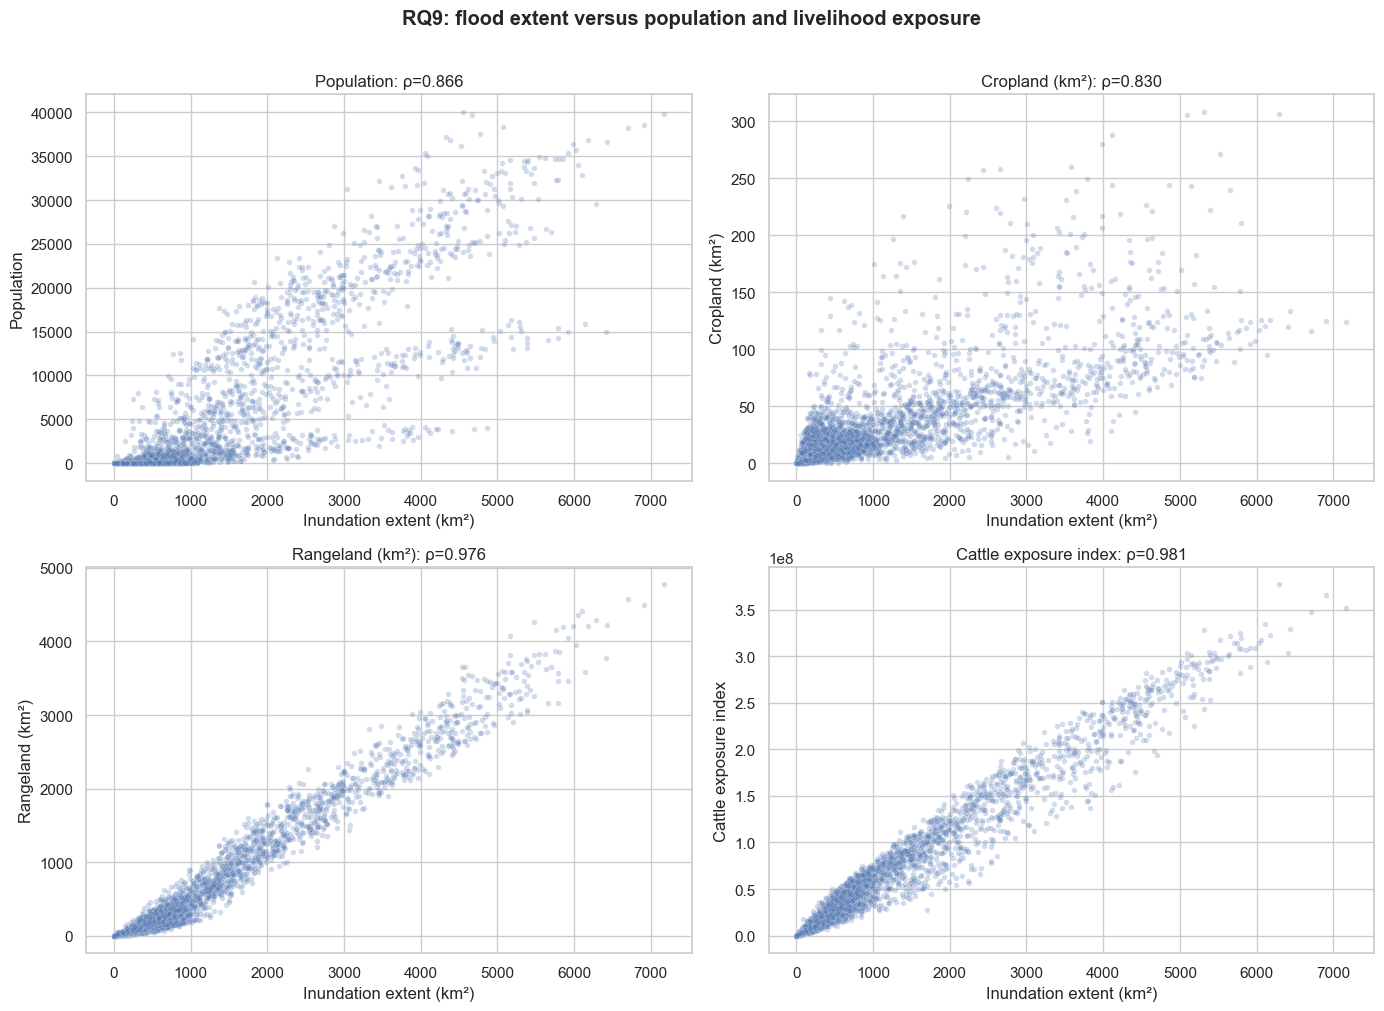

,exposure,spearman_rho,p_value,n_dates
0,Population,0.866120,0.0,3996
1,Cropland (km²),0.830034,0.0,3996
2,Rangeland (km²),0.975929,0.0,3996
3,Cattle exposure index,0.980563,0.0,3996


**Large population exposure despite relatively smaller extent**

,date,inundation_km2,population_exposed_est,rank_gap
2651,2022-04-14,45.115428,760.492676,0.601602
3507,2024-08-21,45.764628,217.970427,0.542668
2986,2023-03-19,145.005230,2528.373369,0.519770
2444,2021-09-18,75.365343,312.006103,0.510260
2116,2020-10-22,54.849108,114.227653,0.502252
2835,2022-10-16,57.671961,74.157601,0.478729
2236,2021-02-20,35.000777,34.525848,0.469469
3508,2024-08-22,1.219317,18.003838,0.461211
2832,2022-10-13,80.801991,119.826363,0.460711
2841,2022-10-22,10.976023,20.202513,0.460210


In [3]:
metrics = {
    "Population": "population_exposed_est", "Cropland (km²)": "crop_exposed_km2",
    "Rangeland (km²)": "rangeland_exposed_km2", "Cattle exposure index": "cattle_exposure_index"}
stats = []
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (label, col) in zip(axes.flat, metrics.items()):
    d = daily[["inundation_km2", col]].replace([np.inf,-np.inf],np.nan).dropna()
    rho, p = spearmanr(d.inundation_km2, d[col])
    stats.append({"exposure":label,"spearman_rho":rho,"p_value":p,"n_dates":len(d)})
    sns.scatterplot(data=d, x="inundation_km2", y=col, s=16, alpha=.25, ax=ax)
    ax.set(title=f"{label}: ρ={rho:.3f}", xlabel="Inundation extent (km²)", ylabel=label)
fig.suptitle("RQ9: flood extent versus population and livelihood exposure", y=1.01, weight="bold")
fig.tight_layout(); fig.savefig(OUT/"rq9_all_exposure_relationships.png", dpi=220, bbox_inches="tight"); plt.show()
rq9_stats = pd.DataFrame(stats); display(rq9_stats); rq9_stats.to_csv(OUT/"rq9_correlations.csv", index=False)

# Counterexamples: compare exposure ranks with inundation ranks.
counter = daily.copy()
counter["extent_percentile"] = counter.inundation_km2.rank(pct=True)
counter["population_percentile"] = counter.population_exposed_est.rank(pct=True)
counter["rank_gap"] = counter.population_percentile - counter.extent_percentile
display(Markdown("**Large population exposure despite relatively smaller extent**"))
display(counter.nlargest(10,"rank_gap")[["date","inundation_km2","population_exposed_est","rank_gap"]])
counter.nlargest(25,"rank_gap").to_csv(OUT/"rq9_counterexamples.csv", index=False)

## 3. RQ9 extension — healthcare facilities as critical infrastructure

A facility is considered exposed on a date when a detected flooded-cell centre lies within approximately **350 m**. This tolerance covers the flood-cell footprint and modest geolocation mismatch.

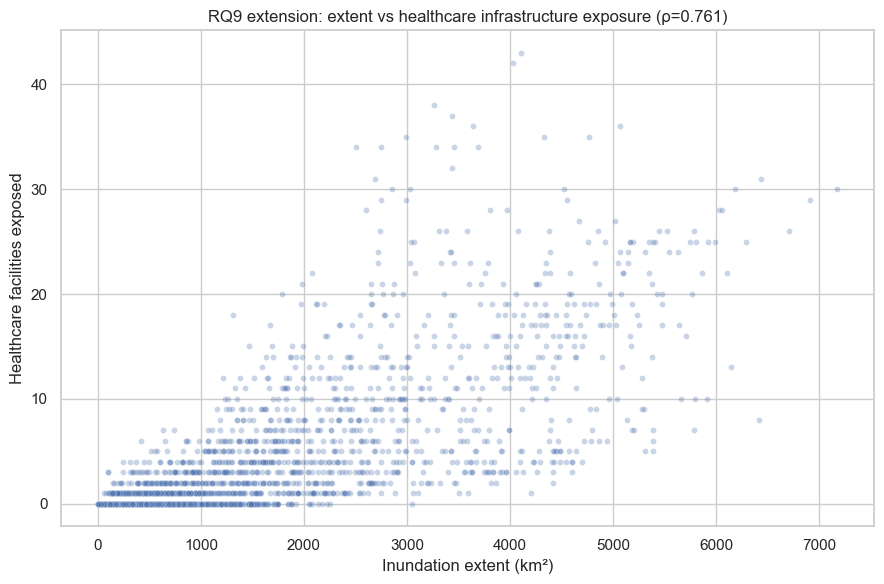

Spearman rho=0.761, p=0, n=3,996


In [4]:
admin0 = gpd.read_file(ADMIN0_FILE).to_crs(4326)
admin1 = gpd.read_file(ADMIN1_FILE).to_crs(4326)
health = gpd.read_file(HEALTH_FILE).to_crs(4326)
health = gpd.sjoin(health, admin0[["geometry"]], predicate="within", how="inner").drop(columns=["index_right"], errors="ignore")
health = health.reset_index(drop=True)
health["facility_id"] = np.arange(len(health))
name_candidates = [c for c in health.columns if any(k in c.lower() for k in ["name","facility","health"])]
NAME_COL = name_candidates[0] if name_candidates else None
health["facility_name"] = health[NAME_COL].astype(str) if NAME_COL else "Facility " + health.facility_id.astype(str)

facility_xy = np.c_[health.geometry.x, health.geometry.y]
daily_facility_rows, facility_events = [], []
threshold_deg = 0.0032
for year in sorted(pop_files):
    pts = read_year(year)
    for date, d in pts.groupby("date"):
        tree = cKDTree(np.c_[d.lon, d.lat])
        dist, _ = tree.query(facility_xy, k=1)
        hit = np.flatnonzero(dist <= threshold_deg)
        daily_facility_rows.append({"date":date,"health_facilities_exposed":len(hit)})
        if len(hit): facility_events.extend((date, int(i)) for i in hit)
daily_health = pd.DataFrame(daily_facility_rows)
daily = daily.merge(daily_health, on="date", how="left").fillna({"health_facilities_exposed":0})
daily["health_facilities_exposed"] = daily.health_facilities_exposed.astype(int)
rho_health, p_health = spearmanr(daily.inundation_km2, daily.health_facilities_exposed)

fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(data=daily, x="inundation_km2", y="health_facilities_exposed", alpha=.3, s=18, ax=ax)
ax.set(title=f"RQ9 extension: extent vs healthcare infrastructure exposure (ρ={rho_health:.3f})",
       xlabel="Inundation extent (km²)", ylabel="Healthcare facilities exposed")
fig.tight_layout(); fig.savefig(OUT/"rq9_extension_health_infrastructure.png",dpi=220); plt.show()
print(f"Spearman rho={rho_health:.3f}, p={p_health:.3g}, n={len(daily):,}")
daily.to_csv(OUT/"daily_complete_exposure.csv", index=False)

## 4. RQ12 — healthcare facilities and population hotspots

,FID,Country,Admin1,Facility_n,Facility_t,Ownership,Lat,Long,LL_source,facility_id,...,valid_to,area_sqkm,version,lang,lang1,lang2,lang3,adm1_ref_name,center_lat,center_lon
1025,55813,South Sudan,Unity,Biel Bar Primary Health Care Unit,Primary Health Care Unit,MoH,8.9790,29.7174,GPS,1025,...,None,37058.934894,v03,en,None,None,None,Unity,8.676570,29.783803
1026,55814,South Sudan,Unity,Biel Chir Primary Health Care Unit,Primary Health Care Unit,MoH,9.0476,29.6894,GPS,1026,...,None,37058.934894,v03,en,None,None,None,Unity,8.676570,29.783803
1134,55922,South Sudan,Unity,Wathnyotni Primary Health Care Unit,Primary Health Care Unit,MoH,9.4928,29.8938,GPS,1134,...,None,37058.934894,v03,en,None,None,None,Unity,8.676570,29.783803
1085,55873,South Sudan,Unity,Nhial Diu Primary Health Care Centre,Primary Health Care Centre,MoH,9.0262,29.6833,Geonames,1085,...,None,37058.934894,v03,en,None,None,None,Unity,8.676570,29.783803
1059,55847,South Sudan,Unity,Kuer Guini Primary Health Care Unit,Primary Health Care Unit,MoH,9.2607,29.8910,GPS,1059,...,None,37058.934894,v03,en,None,None,None,Unity,8.676570,29.783803
1086,55874,South Sudan,Unity,Niemni Primary Health Care Unit,Primary Health Care Unit,MoH,9.3065,30.0263,GPS,1086,...,None,37058.934894,v03,en,None,None,None,Unity,8.676570,29.783803
1130,55918,South Sudan,Unity,UNMISS PoC Sector 4 Primary Health Care Unit,Primary Health Care Unit,MoH,9.2569,29.7772,Geonames,1130,...,None,37058.934894,v03,en,None,None,None,Unity,8.676570,29.783803
676,55463,South Sudan,Jonglei,Kongor Primary Health Care Unit,Primary Health Care Unit,MoH,7.1562,31.3553,GPS,676,...,None,121917.698774,v03,en,None,None,None,Jonglei,7.620470,32.148730
766,55553,South Sudan,Jonglei,Wangulei Primary Health Care Unit,Primary Health Care Unit,MoH,7.0848,31.3775,GPS,766,...,None,121917.698774,v03,en,None,None,None,Jonglei,7.620470,32.148730
1035,55823,South Sudan,Unity,Chol Yiel Primary Health Care Unit,Primary Health Care Unit,MoH,9.0706,29.9256,GPS,1035,...,None,37058.934894,v03,en,None,None,None,Unity,8.676570,29.783803


,lon,lat,exposed_dates,mean_population,cumulative_person_date_exposure,index_right,adm1_name,adm1_name1,adm1_name2,adm1_name3,...,valid_to,area_sqkm,version,lang,lang1,lang2,lang3,adm1_ref_name,center_lat,center_lon
17200,29.651041,9.144792,862,2.830782,2440.133938,5.0,Unity,None,None,None,...,None,37058.934894,v03,en,None,None,None,Unity,8.67657,29.783803
17199,29.651041,9.140625,859,14.243248,12234.949836,5.0,Unity,None,None,None,...,None,37058.934894,v03,en,None,None,None,Unity,8.67657,29.783803
17201,29.651041,9.146875,856,15.288777,13087.193488,5.0,Unity,None,None,None,...,None,37058.934894,v03,en,None,None,None,Unity,8.67657,29.783803
17316,29.655209,9.138541,854,16.579311,14158.731931,5.0,Unity,None,None,None,...,None,37058.934894,v03,en,None,None,None,Unity,8.67657,29.783803
17257,29.653126,9.138541,854,0.160311,136.905458,5.0,Unity,None,None,None,...,None,37058.934894,v03,en,None,None,None,Unity,8.67657,29.783803
17317,29.655209,9.140625,853,4.111165,3506.824063,5.0,Unity,None,None,None,...,None,37058.934894,v03,en,None,None,None,Unity,8.67657,29.783803
17260,29.653126,9.144792,853,2.583182,2203.454499,5.0,Unity,None,None,None,...,None,37058.934894,v03,en,None,None,None,Unity,8.67657,29.783803
17389,29.657291,9.138541,853,1.741710,1485.678934,5.0,Unity,None,None,None,...,None,37058.934894,v03,en,None,None,None,Unity,8.67657,29.783803
17390,29.657291,9.148958,853,0.369266,314.984242,5.0,Unity,None,None,None,...,None,37058.934894,v03,en,None,None,None,Unity,8.67657,29.783803
17261,29.653126,9.146875,852,0.308448,262.797693,5.0,Unity,None,None,None,...,None,37058.934894,v03,en,None,None,None,Unity,8.67657,29.783803


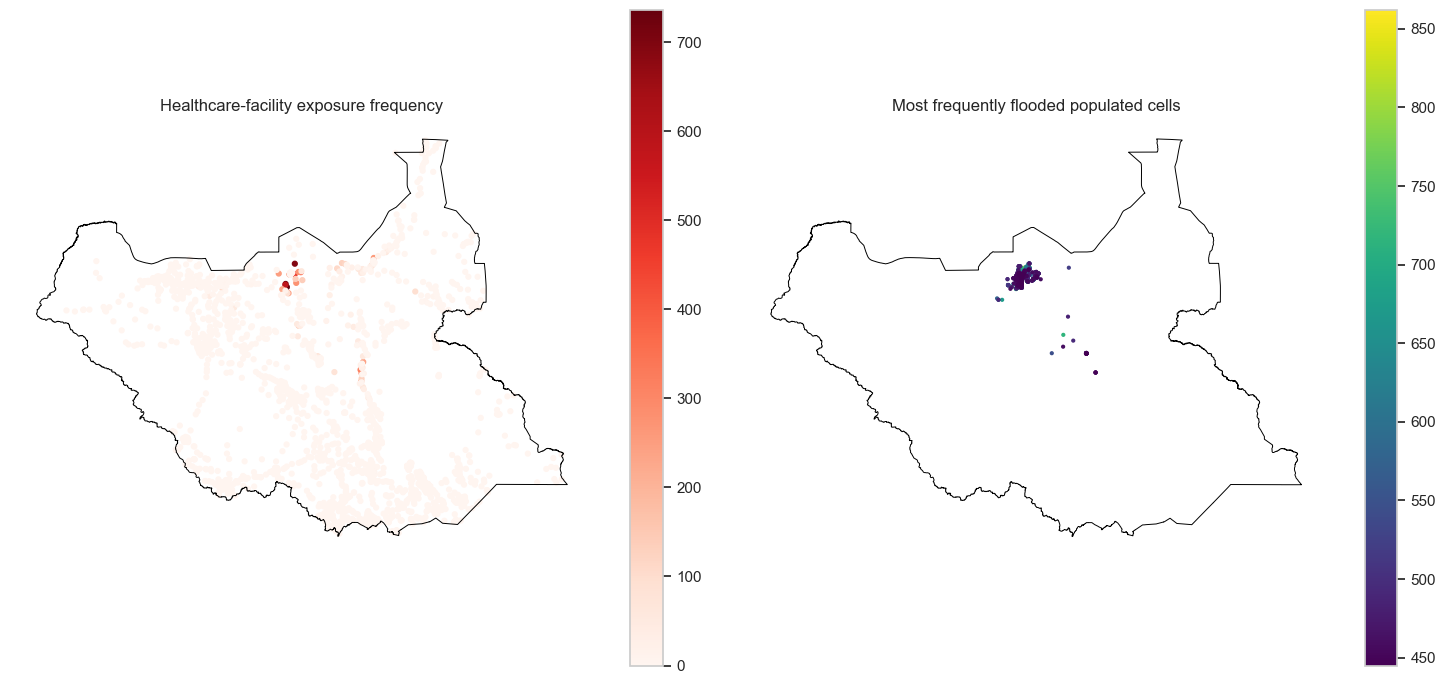

In [5]:
events = pd.DataFrame(facility_events, columns=["date","facility_id"])
if events.empty:
    facility_rank = health[["facility_id","facility_name","geometry"]].copy()
    facility_rank["exposed_dates"] = 0
else:
    counts = events.groupby("facility_id").agg(exposed_dates=("date","nunique"), first_exposure=("date","min"), last_exposure=("date","max")).reset_index()
    facility_rank = health.merge(counts, on="facility_id", how="left")
    facility_rank["exposed_dates"] = facility_rank.exposed_dates.fillna(0).astype(int)
facility_rank = gpd.sjoin(facility_rank, admin1, predicate="within", how="left", lsuffix="facility", rsuffix="admin1")
facility_rank = facility_rank.sort_values("exposed_dates", ascending=False)
display(facility_rank.drop(columns="geometry").head(25))
facility_rank.drop(columns="geometry").head(100).to_csv(OUT/"rq12_health_facility_ranking.csv", index=False)

hot = populated_points.groupby(["lon","lat"], as_index=False).agg(
    exposed_dates=("date","nunique"), mean_population=("population","mean"),
    cumulative_person_date_exposure=("population","sum"))
hot = gpd.GeoDataFrame(hot, geometry=gpd.points_from_xy(hot.lon,hot.lat), crs=4326)
hot = gpd.sjoin(hot, admin1, predicate="within", how="left")
hot = hot.sort_values(["exposed_dates","cumulative_person_date_exposure"], ascending=False)
display(hot.drop(columns="geometry").head(25))
hot.drop(columns="geometry").head(100).to_csv(OUT/"rq12_population_hotspot_ranking.csv", index=False)

fig, axes = plt.subplots(1,2,figsize=(15,7))
admin0.boundary.plot(ax=axes[0], color="black", linewidth=.7)
facility_rank.plot(ax=axes[0], column="exposed_dates", cmap="Reds", markersize=12, legend=True)
axes[0].set_title("Healthcare-facility exposure frequency"); axes[0].set_axis_off()
admin0.boundary.plot(ax=axes[1], color="black", linewidth=.7)
hot.head(2500).plot(ax=axes[1], column="exposed_dates", cmap="viridis", markersize=4, legend=True)
axes[1].set_title("Most frequently flooded populated cells"); axes[1].set_axis_off()
fig.tight_layout(); fig.savefig(OUT/"rq12_health_and_population_hotspots.png",dpi=220,bbox_inches="tight"); plt.show()

## 5. Data-driven conclusions

In [8]:
def strength(r):
    a=abs(r)
    return "very weak" if a<.2 else "weak" if a<.4 else "moderate" if a<.6 else "strong" if a<.8 else "very strong"

best_fac = facility_rank.iloc[0]
best_hot = hot.iloc[0]
lines = ["### RQ9",
         f"Flood extent showed a **{strength(rq9_stats.iloc[0].spearman_rho)} positive association** with population exposure (ρ={rq9_stats.iloc[0].spearman_rho:.3f}). "
         "However, the rank counterexamples demonstrate that larger inundation does **not necessarily** produce greater exposure: location and overlap with populated/livelihood areas matter.",
         "Livelihood results: " + "; ".join(f"{r.exposure}: ρ={r.spearman_rho:.3f}" for r in rq9_stats.iloc[1:].itertuples()),
         "### RQ9 extension",
         f"Inundation extent and exposed healthcare facilities had a **{strength(rho_health)} positive association** (ρ={rho_health:.3f}). Healthcare facilities are the supplied critical-infrastructure layer; roads/buildings are outside this dataset.",
         "### RQ12",
         f"The most frequently exposed recorded facility was **{best_fac.facility_name}**, exposed on {int(best_fac.exposed_dates)} distinct flood dates. "
         f"The leading populated hotspot was near ({best_hot.lat:.4f}, {best_hot.lon:.4f}), flooded on {int(best_hot.exposed_dates)} distinct dates.",
         "### Limitations",
         "Facility exposure uses a 350 m proximity rule; cattle values are reported as an exposure index unless the source metadata confirms exact livestock-count units; satellite observations are not continuous and therefore frequencies represent observed flood dates, not all actual flood days."]
display(Markdown("\n\n".join(lines)))
print("Outputs saved to", OUT.relative_to(PROJECT_ROOT))

### RQ9

Flood extent showed a **very strong positive association** with population exposure (ρ=0.866). However, the rank counterexamples demonstrate that larger inundation does **not necessarily** produce greater exposure: location and overlap with populated/livelihood areas matter.

Livelihood results: Cropland (km²): ρ=0.830; Rangeland (km²): ρ=0.976; Cattle exposure index: ρ=0.981

### RQ9 extension

Inundation extent and exposed healthcare facilities had a **strong positive association** (ρ=0.761). Healthcare facilities are the supplied critical-infrastructure layer; roads/buildings are outside this dataset.

### RQ12

The most frequently exposed recorded facility was **Biel Bar Primary Health Care Unit**, exposed on 736 distinct flood dates. The leading populated hotspot was near (9.1448, 29.6510), flooded on 862 distinct dates.

### Limitations

Facility exposure uses a 350 m proximity rule; cattle values are reported as an exposure index unless the source metadata confirms exact livestock-count units; satellite observations are not continuous and therefore frequencies represent observed flood dates, not all actual flood days.

Outputs saved to results/rq9_rq12_complete
